<a href="https://colab.research.google.com/github/wasimnawaz1/programming_4_AI/blob/main/Programming_4_AI%2C_Lectures_(Week_10)_OOP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 10: Introduction to **AI271 Programming for AI**

### **Link to find the lecture:**
https://github.com/wasimnawaz1/programming_4_AI

### Python Object-Oriented Programming (OOP)

**Topics Covered:**
- Classes & Objects
- Attributes & Methods
- Constructors
- Encapsulation
- Inheritance
- Polymorphism
- Method Overriding
- Building Dataset Classes



### What is OOP?

**Object-Oriented Programming (OOP)** is a programming framework (system of rules and ideas) that organizes software design around **data (objects)** rather than functions and logic. It models real-world entities as objects that have:

- **State** → stored in *attributes* (data/variables)
- **Behavior** → expressed through *methods* (functions)

#### Pillars of OOP

| Pillar | Description |
|---|---|
| **Encapsulation** | Hiding internal state of data and methods|
| **Inheritance** | Deriving new classes from existing ones |
| **Polymorphism** | Same interface (function or object) performing different actions |
| **Abstraction** | Exposing only essential details |

---

### Classes and Objects

A **class** is a *blueprint* or *template* for creating objects. Think of it like an architectural plan for a house — the plan itself is not a house, but you can build many houses from it.

```
Class  →  Blueprint / Template
Object →  Instance created from that blueprint
```

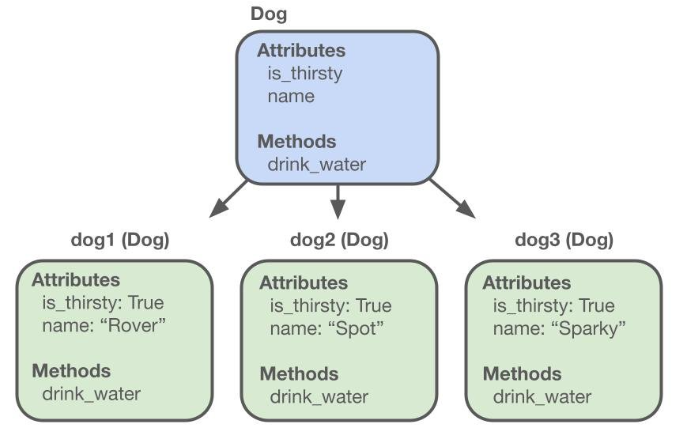


### An Example of Class Diagram

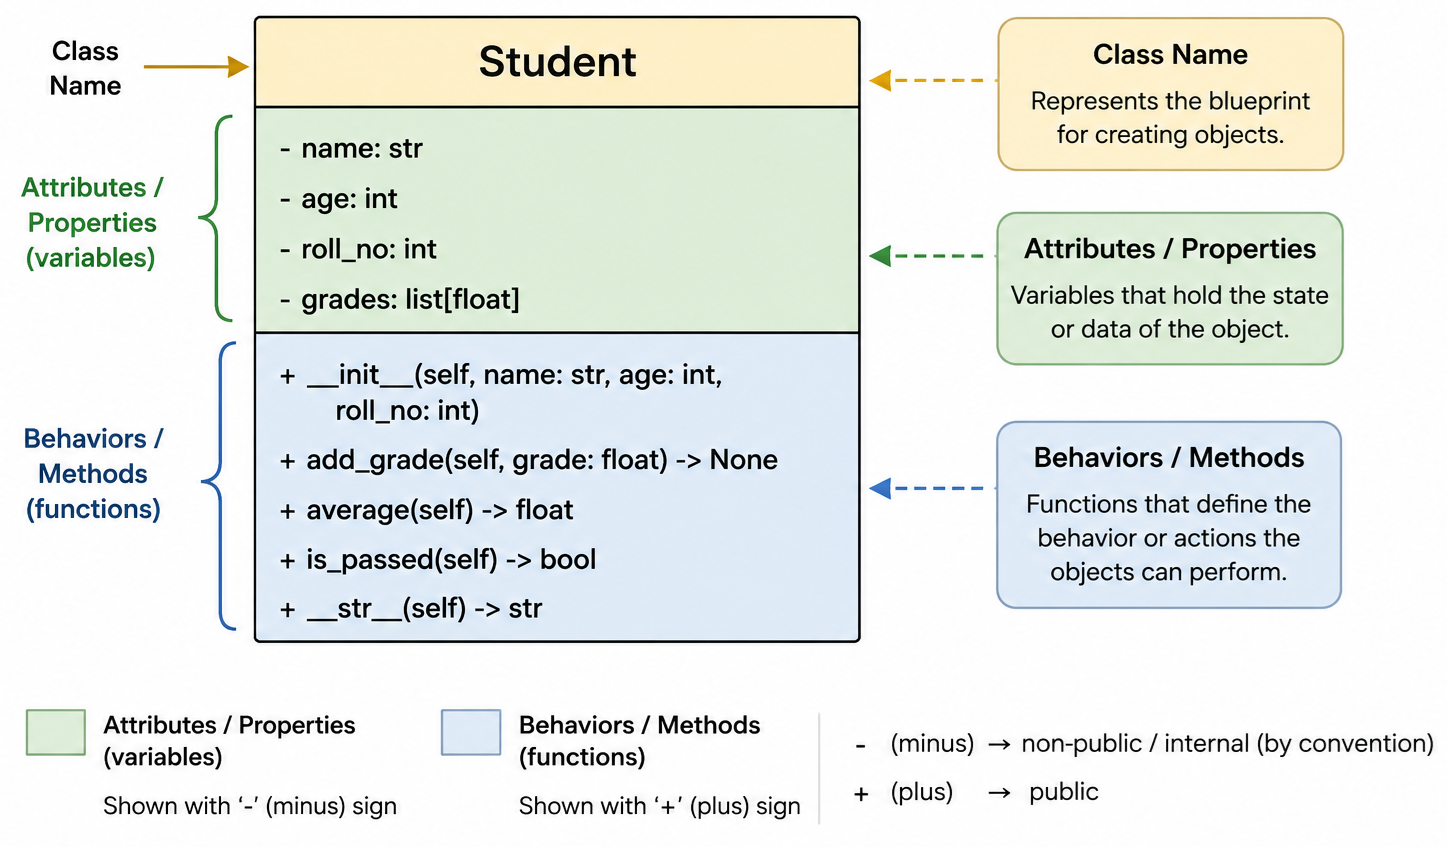



### What is an Object?
An **object** (also called an *instance*) is a concrete realization of a class. Each object:
- Has its own copy of the class's attributes
- Can call the methods defined in the class
- Lives independently in memory

#### Syntax

```python
class ClassName:
    # class body: attributes and methods
    pass

# Create an object (instantiation)
obj = ClassName()
```

#### Real-World Analogy
| Class | Objects (Instances) |
|---|---|
| `Car` blueprint | Your red Toyota, neighbour's blue Honda |
| `Student` template | Alice (age 20), Bob (age 22) |
| `NeuralNetwork` | model_1 (2 layers), model_2 (5 layers) |

In [ ]:
# Defining a simple class

class Dog:
    """A simple class representing a dog."""
    pass  # empty body — `pass` is a placeholder, it is used when code is required but no action is needed.

# Instantiate (create) objects from the class
dog1 = Dog()
dog2 = Dog()

print(type(dog1))              # a class named Dog defined in the main module
print(isinstance(dog1, Dog))   # checks if an object belongs to a particular class
print(dog1 is dog2)            # `is` checks if two variables refer to the same object in memory
print(id(dog1), id(dog2))      # unique memory address (identity) of an object

<class '__main__.Dog'>
True
False
140099336773920 140099336778672


### Constructors (`__init__`)

A **constructor** is a special method that is **automatically called** whenever a new object is created from a class. In Python, the constructor is the `__init__` method.

```python
class MyClass:
    def __init__(self, param1, param2):
        self.attr1 = param1  # initialize instance state
        self.attr2 = param2
```

#### The `self` Parameter
- `self` is a **reference to the current object** being created
- It is automatically passed by Python — you never pass it explicitly when creating objects
- By convention the name is `self` (but technically any name works)
- Using `self.x = value` creates an **instance attribute**
- `self` allows each object to store and access its own data and methods.

#### Python's Object Creation Lifecycle

```
MyClass(args)  →  __new__() creates empty object  →  __init__() fills it  →  object returned
```

In [ ]:
# Class with Class-Level Attributes
# Class attributes are SHARED by ALL instances

class Planet:
    """Represents a planet in our solar system."""
    galaxy = "Milky Way"        # class attribute — shared
    object_count = 0            # tracks how many planets were created

    def __init__(self, name, radius_km):
        self.name = name
        self.radius_km = radius_km
        Planet.object_count += 1   # update class-level counter

earth  = Planet("Earth",  6371)
mars   = Planet("Mars",   3390)
saturn = Planet("Saturn", 58232)

print(f"Galaxy: {Planet.galaxy}")          # Milky Way
print(f"Planets created: {Planet.object_count}")  # 3
print(f"{earth.name} radius: {earth.radius_km} km")

# Accessing class attribute through an instance
print(f"{mars.name} is in the {mars.galaxy}")  # Mars is in the Milky Way

Galaxy: Milky Way
Planets created: 3
Earth radius: 6371 km
Mars is in the Milky Way


In [ ]:
# Multiple Objects — Independent State

class Student:
    """Represents a university student."""

    def __init__(self, name, age, gpa):
        self.name = name
        self.age  = age
        self.gpa  = gpa

    def introduce(self):
        return (f"Hi! I'm {self.name}, {self.age} years old, "
                f"GPA: {self.gpa:.2f}")

# Create several independent student objects
students = [
    Student("Alice",   20, 3.9),
    Student("Bob",     22, 3.5),
    Student("Charlie", 21, 3.7),
]

for s in students:
    print(s.introduce())

# Mutating one object does NOT affect others
students[0].gpa = 4.0
print(f"\nAfter update — Alice's GPA: {students[0].gpa}")
print(f"Bob's GPA unchanged: {students[1].gpa}")

Hi! I'm Alice, 20 years old, GPA: 3.90
Hi! I'm Bob, 22 years old, GPA: 3.50
Hi! I'm Charlie, 21 years old, GPA: 3.70

After update — Alice's GPA: 4.0
Bob's GPA unchanged: 3.5


In [ ]:
# Inspecting Objects with Built-in Functions

class Car:
    brand = "Generic"

    def __init__(self, model, year, color):
        self.model = model
        self.year  = year
        self.color = color

    def description(self):
        return f"{self.year} {self.color} {self.model}"

my_car = Car("Tesla Model 3", 2023, "red")

# Introspection tools
print("dir() (filtered):", [a for a in dir(my_car) if not a.startswith('__')])
# print("dir():", [a for a in dir(my_car) if a.startswith('__')])
print("__dict__:",          my_car.__dict__)
print("hasattr model:",     hasattr(my_car, 'model'))
print("getattr model:",     getattr(my_car, 'model'))
print("type:",              type(my_car))
print("isinstance Car:",    isinstance(my_car, Car))

# Dynamically add an attribute at runtime
my_car.mileage = 12_500
print("After setattr:",     my_car.__dict__)

dir() (filtered): ['brand', 'color', 'description', 'model', 'year']
__dict__: {'model': 'Tesla Model 3', 'year': 2023, 'color': 'red'}
hasattr model: True
getattr model: Tesla Model 3
type: <class '__main__.Car'>
isinstance Car: True
After setattr: {'model': 'Tesla Model 3', 'year': 2023, 'color': 'red', 'mileage': 12500}


### Attributes
Attributes store the **state** of an object. Python has three main kinds:

| Type | Scope | Defined in |
|---|---|---|
| **Instance attribute** | Unique per object | `__init__` via `self.x = ...` |
| **Class attribute** | Shared by all instances | Class body, outside any method |
| **Class variable (mutable)** | Shared reference like lists etc. that can change  | Class body, outside any method |


In [ ]:
# Instance vs Class Attributes

class BankAccount:
    bank_name    = "PyBank"      # class attribute — same for all accounts
    interest_rate = 0.035        # 3.5% annual — same for all

    def __init__(self, owner, balance=0.0):
        self.owner   = owner     # instance attribute — unique per account
        self.balance = balance

    def deposit(self, amount):
        self.balance += amount
        print(f"  Deposited ${amount:.2f}. New balance: ${self.balance:.2f}")

    def withdraw(self, amount):
        if amount > self.balance:
            print("  Insufficient funds!")
        else:
            self.balance -= amount
            print(f"  Withdrew ${amount:.2f}. Remaining: ${self.balance:.2f}")

    def apply_interest(self):
        earned = self.balance * BankAccount.interest_rate
        self.balance += earned
        print(f"  Interest applied: ${earned:.2f}")

acc1 = BankAccount("Alice", 1000)
acc2 = BankAccount("Bob",   500)

print(f"Bank: {BankAccount.bank_name}")
acc1.deposit(200)
acc1.apply_interest()
acc2.withdraw(600)   # should fail
print(f"Alice balance: ${acc1.balance:.2f}")

Bank: PyBank
  Deposited $200.00. New balance: $1200.00
  Interest applied: $42.00
  Insufficient funds!
Alice balance: $1242.00


### Methods

Methods define the **behavior** of an object. There are three types:

| Method Type | Decorator | First Parameter | Use Case |
|---|---|---|---|
| **Instance method** | *(none)* | `self` | Operates on instance data |
| **Class method** | `@classmethod` | `cls` | Operates on class-level data; alternate constructors |
| **Static method** | `@staticmethod` | *(none)* | Utility function logically grouped with the class |

`cls` refers to the class itself, just like `self` refers to the current object (instance).

It is used inside a @classmethod.

#### Special (Dunder) Methods
Python calls these **automatically** in certain contexts:

| Dunder | Called when |
|---|---|
| `__init__` | Object is created |
| `__str__` | `str(obj)` / `print(obj)` |
| `__repr__` | `repr(obj)` |
| `__len__` | `len(obj)` |
| `__add__` | `obj1 + obj2` |

In [ ]:
# Class Methods and Static Methods

class Temperature:
    """Temperature class with multiple unit support."""

    def __init__(self, celsius):
        self.celsius = celsius

    # ── Class method: alternative constructor ────────────
    @classmethod
    def from_fahrenheit(cls, f):
        """Create Temperature from a Fahrenheit value."""
        return cls((f - 32) * 5 / 9)

    @classmethod
    def from_kelvin(cls, k):
        """Create Temperature from a Kelvin value."""
        return cls(k - 273.15)

    # ── Static method: utility, no instance/class needed ─
    @staticmethod
    def is_freezing(celsius):
        return celsius <= 0

    @staticmethod
    def celsius_to_fahrenheit(c):
        return c * 9 / 5 + 32

    # ── Instance method ──────────────────────────────────
    def to_fahrenheit(self):
        return Temperature.celsius_to_fahrenheit(self.celsius)

    def __str__(self):
        return f"{self.celsius:.2f}°C / {self.to_fahrenheit():.2f}°F"

# Using all three method types
t1 = Temperature(100)                      # boiling point
t2 = Temperature.from_fahrenheit(32)       # freezing in Fahrenheit
t3 = Temperature.from_kelvin(300)          # Kelvin

print(t1)
print(t2)
print(t3)
print(f"Is 0°C freezing? {Temperature.is_freezing(0)}")
print(f"Is 5°C freezing? {Temperature.is_freezing(5)}")

100.00°C / 212.00°F
0.00°C / 32.00°F
26.85°C / 80.33°F
Is 0°C freezing? True
Is 5°C freezing? False


In [ ]:
# Special (Dunder) Methods

class Vector:
    """2D mathematical vector with operator overloading."""

    def __init__(self, x, y):
        self.x = x
        self.y = y

    def __str__(self):
        return f"Vector({self.x}, {self.y})"

    def __repr__(self):
        return f"Vector(x={self.x!r}, y={self.y!r})"

    def __add__(self, other):
        return Vector(self.x + other.x, self.y + other.y)

    def __sub__(self, other):
        return Vector(self.x - other.x, self.y - other.y)

    def __mul__(self, scalar):
        return Vector(self.x * scalar, self.y * scalar)

    def __eq__(self, other):
        return self.x == other.x and self.y == other.y

    def __len__(self):
        return 2   # a 2D vector always has 2 components

    def magnitude(self):
        return (self.x**2 + self.y**2) ** 0.5

v1 = Vector(3, 4)
v2 = Vector(1, 2)

print(f"v1        : {v1}")
print(f"v2        : {v2}")
print(f"v1 + v2   : {v1 + v2}")
print(f"v1 - v2   : {v1 - v2}")
print(f"v1 * 3    : {v1 * 3}")
print(f"v1 == v2  : {v1 == v2}")
print(f"|v1|      : {v1.magnitude():.3f}")
print(f"len(v1)   : {len(v1)}")
print(f"repr(v1)  : {repr(v1)}")

v1        : Vector(3, 4)
v2        : Vector(1, 2)
v1 + v2   : Vector(4, 6)
v1 - v2   : Vector(2, 2)
v1 * 3    : Vector(9, 12)
v1 == v2  : False
|v1|      : 5.000
len(v1)   : 2
repr(v1)  : Vector(x=3, y=4)


In [ ]:
# Properties — Computed Attributes
# Properties let you use method logic behind attribute syntax
# `@property` allows a method to be accessed like an attribute (variable) instead of calling it like a function.

class Circle:
    PI = 3.141592653589793

    def __init__(self, radius):
        self._radius = radius   # convention: underscore = internal

    @property
    def radius(self):
        """Getter."""
        return self._radius

    @radius.setter
    def radius(self, value):
        """Setter with validation."""
        if value < 0:
            raise ValueError("Radius cannot be negative.")
        self._radius = value

    @property
    def diameter(self):
        return self._radius * 2

    @property
    def area(self):
        return Circle.PI * self._radius ** 2

    @property
    def circumference(self):
        return 2 * Circle.PI * self._radius

    def __str__(self):
        return (f"Circle(r={self.radius}) "
                f"area={self.area:.3f}, "
                f"circumference={self.circumference:.3f}")

c = Circle(5)
print(c)
print(f"Diameter: {c.diameter}")

c.radius = 10
print(c)

try:
    c.radius = -1  # triggers ValueError
except ValueError as e:
    print(f"Error: {e}")

Circle(r=5) area=78.540, circumference=31.416
Diameter: 10
Circle(r=10) area=314.159, circumference=62.832
Error: Radius cannot be negative.


### Encapsulation

#### What is Encapsulation?
**Encapsulation** is the principle of **bundling data (attributes) and the methods that operate on that data** together inside a class, and **restricting direct access** to some of the object's components.

This means:
- Internal implementation details are **hidden** from the outside
- The object exposes only what's necessary via a **public interface**
- Data integrity is protected through **controlled access**

#### Python's Access Conventions

Python uses **naming conventions** (not true enforcement) to signal access levels:

| Naming | Convention | Access Level | Description |
|---|---|---|---|
| `name` | No underscore | **Public** | Freely accessible from anywhere |
| `_name` | Single underscore | **Protected** | "Please don't touch" — still accessible |
| `__name` | Double underscore | **Private** | Name mangling: `_ClassName__name` |

#### Why Encapsulate?

- **Data validation**: enforce rules when setting values
- **Abstraction**: users don't need to know how it works internally
- **Flexibility**: change internal implementation without breaking callers
- **Security**: prevent accidental corruption of critical state

In [ ]:
# Public, Protected, and Private Attributes

class UserAccount:
    MAX_LOGIN_ATTEMPTS = 3  # public class attribute

    def __init__(self, username, email, password):
        self.username        = username          # public
        self._email          = email             # protected
        self.__password      = password          # private (name-mangled)
        self.__login_attempts = 0               # private
        self._active         = True             # protected

    def login(self, password_attempt):
        if not self._active:
            return "Account is locked!"
        if password_attempt == self.__password:
            self.__login_attempts = 0
            return f"✅ Welcome, {self.username}!"
        else:
            self.__login_attempts += 1
            remaining = self.MAX_LOGIN_ATTEMPTS - self.__login_attempts
            if remaining <= 0:
                self._active = False
                return "🔒 Account LOCKED due to too many failed attempts."
            return f"❌ Wrong password. {remaining} attempt(s) left."

    def get_email(self):
        """Controlled access to protected attribute."""
        masked = self._email[:2] + "***" + self._email[self._email.index('@'):]
        return masked

    def change_password(self, old_pw, new_pw):
        if old_pw == self.__password:
            self.__password = new_pw
            return "Password changed successfully."
        return "Old password incorrect."

user = UserAccount("alice_dev", "alice@example.com", "s3cr3t!")

print(user.login("wrong"))
print(user.login("wrong"))
print(user.login("wrong"))   # locks the account
print(user.login("s3cr3t!")) # account is now locked

print(f"\nEmail (masked): {user.get_email()}")
# Attempting to access private attribute directly
try:
    print(user.__password)
except AttributeError as e:
    print(f"Direct access failed: {e}")

# Name mangling reveals the actual name
print(f"Via mangling: {user._UserAccount__password}")

In [ ]:
# Getters and Setters with @property

class Rectangle:
    """Rectangle with validated dimensions."""

    def __init__(self, width, height):
        self.width  = width    # calls the setter
        self.height = height

    @property
    def width(self):
        return self.__width

    @width.setter
    def width(self, value):
        if not isinstance(value, (int, float)) or value <= 0:
            raise ValueError(f"Width must be a positive number, got {value!r}")
        self.__width = float(value)

    @property
    def height(self):
        return self.__height

    @height.setter
    def height(self, value):
        if not isinstance(value, (int, float)) or value <= 0:
            raise ValueError(f"Height must be a positive number, got {value!r}")
        self.__height = float(value)

    @property
    def area(self):
        return self.__width * self.__height

    @property
    def perimeter(self):
        return 2 * (self.__width + self.__height)

    @property
    def is_square(self):
        return self.__width == self.__height

    def __str__(self):
        return (f"Rectangle({self.width} x {self.height}) "
                f"area={self.area}, perimeter={self.perimeter}, "
                f"square={self.is_square}")

r = Rectangle(4, 6)
print(r)

r.width = 6
print(r)  # now it's a square

try:
    r.width = -3
except ValueError as e:
    print(f"Error: {e}")

try:
    r.height = "big"
except ValueError as e:
    print(f"Error: {e}")

In [ ]:
# Homework Example: Encapsulating Complex State — Medical Record

from datetime import datetime

class MedicalRecord:
    """Highly encapsulated patient record."""

    def __init__(self, patient_id, name, dob):
        self.__patient_id  = patient_id
        self.__name        = name
        self.__dob         = dob
        self.__diagnoses   = []   # private list
        self.__medications = []   # private list
        self.__access_log  = []   # audit trail

    def _log_access(self, action, actor):
        timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        self.__access_log.append(f"[{timestamp}] {actor} → {action}")

    def add_diagnosis(self, diagnosis, doctor):
        self.__diagnoses.append(diagnosis)
        self._log_access(f"Added diagnosis: {diagnosis}", doctor)

    def prescribe(self, medication, doctor):
        self.__medications.append(medication)
        self._log_access(f"Prescribed: {medication}", doctor)

    def get_summary(self, requester):
        self._log_access("Viewed summary", requester)
        return {
            "id":          self.__patient_id,
            "name":        self.__name,
            "diagnoses":   list(self.__diagnoses),
            "medications": list(self.__medications),
        }

    def get_audit_log(self, admin_key):
        if admin_key != "ADMIN_SECRET":
            return "Access denied."
        return list(self.__access_log)

record = MedicalRecord("P-001", "John Doe", "1985-04-12")
record.add_diagnosis("Type 2 Diabetes", "Dr. Smith")
record.add_diagnosis("Hypertension",    "Dr. Smith")
record.prescribe("Metformin 500mg",     "Dr. Smith")

import json
print(json.dumps(record.get_summary("Dr. Jones"), indent=2))
print("\nAudit Log:")
for entry in record.get_audit_log("ADMIN_SECRET"):
    print(f"  {entry}")

### Inheritance and Polymorphism

#### Inheritance
**Inheritance** allows a class (the *child* or *subclass*) to **reuse, extend, or modify** the behavior of another class (the *parent* or *superclass*).

```python
class Animal:            # Parent / Base / Superclass
    ...

class Dog(Animal):       # Child / Derived / Subclass
    ...                  # inherits everything from Animal
```

#### Types of Inheritance in Python

| Type | Description | Example |
|---|---|---|
| **Single** | One parent | `Dog(Animal)` |
| **Multi-level** | Chain of parents | `GoldenRetriever(Dog)` → `Dog(Animal)` |
| **Multiple** | More than one parent | `Amphibian(Water, Land)` |
| **Hierarchical** | Multiple children from one parent | `Dog(Animal)`, `Cat(Animal)` |

#### Polymorphism
**Polymorphism** (Greek: *many forms*) means that **different classes can be used through the same interface**, and each responds in its own way.

```python
# Same method name, different behaviour per class
for animal in [Dog(), Cat(), Bird()]:
    animal.speak()  # each produces its own sound
```

#### `super()` Function
- `super()` gives access to the **parent class's methods**
- Essential when overriding methods but still wanting parent behavior

In [ ]:
# Single Inheritance

class Animal:
    """Base class for all animals."""

    def __init__(self, name, species, age):
        self.name    = name
        self.species = species
        self.age     = age

    def breathe(self):
        return f"{self.name} is breathing."

    def eat(self, food):
        return f"{self.name} is eating {food}."

    def speak(self):
        return f"{self.name} makes a sound."

    def __str__(self):
        return f"{self.species} named '{self.name}', age {self.age}"


class Dog(Animal):
    """Dog — extends Animal."""

    def __init__(self, name, age, breed):
        super().__init__(name, species="Canis lupus familiaris", age=age)
        self.breed = breed
        self.tricks = []

    def speak(self):                      # override parent method
        return f"{self.name} says: Woof! 🐕"

    def learn_trick(self, trick):
        self.tricks.append(trick)
        return f"{self.name} learned: {trick}"

    def show_tricks(self):
        if self.tricks:
            return f"{self.name}'s tricks: {', '.join(self.tricks)}"
        return f"{self.name} knows no tricks yet."

    def __str__(self):
        return f"Dog: {self.name} ({self.breed}), age {self.age}"


class Cat(Animal):
    """Cat — extends Animal."""

    def __init__(self, name, age, indoor=True):
        super().__init__(name, species="Felis catus", age=age)
        self.indoor = indoor

    def speak(self):
        return f"{self.name} says: Meow! 🐱"

    def purr(self):
        return f"{self.name} purrs contentedly... 😸"


rex  = Dog("Rex", 3, "German Shepherd")
luna = Cat("Luna", 5)

print(rex)
print(luna)
print(rex.speak())
print(luna.speak())
print(rex.breathe())    # inherited from Animal
print(rex.eat("bones")) # inherited from Animal
rex.learn_trick("sit")
rex.learn_trick("fetch")
print(rex.show_tricks())
print(luna.purr())

# isinstance hierarchy
print(f"\nrex  is Dog   : {isinstance(rex, Dog)}")
print(f"rex  is Animal: {isinstance(rex, Animal)}")  # True!
print(f"luna is Dog   : {isinstance(luna, Dog)}")   # False

In [ ]:
# Polymorphism
# Same function call, different behavior depending on object type

from abc import ABC, abstractmethod
import math

class Shape(ABC):
    """Abstract base class — cannot be instantiated."""

    @abstractmethod
    def area(self) -> float:
        pass

    @abstractmethod
    def perimeter(self) -> float:
        pass

    def describe(self):   # concrete method in ABC
        return (f"{self.__class__.__name__}: "
                f"area={self.area():.3f}, "
                f"perimeter={self.perimeter():.3f}")


class CircleShape(Shape):
    def __init__(self, radius):
        self.radius = radius
    def area(self):
        return math.pi * self.radius ** 2
    def perimeter(self):
        return 2 * math.pi * self.radius


class RectangleShape(Shape):
    def __init__(self, w, h):
        self.w = w; self.h = h
    def area(self):
        return self.w * self.h
    def perimeter(self):
        return 2 * (self.w + self.h)


class Triangle(Shape):
    def __init__(self, a, b, c):
        self.a = a; self.b = b; self.c = c
    def area(self):
        s = self.perimeter() / 2
        return math.sqrt(s * (s-self.a) * (s-self.b) * (s-self.c))
    def perimeter(self):
        return self.a + self.b + self.c


# Polymorphic usage — single loop, multiple behaviors
shapes = [
    CircleShape(5),
    RectangleShape(4, 6),
    Triangle(3, 4, 5),
    CircleShape(10),
]

print("All shapes:")
for shape in shapes:
    print(f"  {shape.describe()}")

# Polymorphic function
def total_area(shape_list):
    return sum(s.area() for s in shape_list)

print(f"\nTotal area: {total_area(shapes):.3f}")
print(f"Largest:    {max(shapes, key=lambda s: s.area()).describe()}")

# Cannot instantiate abstract class
try:
    Shape()
except TypeError as e:
    print(f"\nABC error: {e}")

### Method Overriding

#### What is Method Overriding?
**Method Overriding** occurs when a **subclass provides its own implementation** of a method that is already defined in its **superclass**.

The overridden method in the child class:
- Has the **same name** as the parent's method
- Takes the **same parameters** (or compatible ones)
- **Replaces** the parent's behavior when called on a child instance

#### Key Concepts

| Concept | Description |
|---|---|
| **Pure override** | Child completely replaces parent method |
| **Extended override** | Child calls `super().method()` THEN adds more |
| **`super()`** | Explicit way to call the parent's version |
| **`__init__` override** | Most common override — customizing construction |

#### Override vs Overload
Python does **not** support method overloading (same name, different signatures) natively, but you can simulate it with default arguments or `*args`.

```
Overriding  = same name, child redefines it
Overloading = same name, different parameters (not native in Python)
```

In [ ]:
# Pure Override and Extended Override

class Logger:
    """Base logger that prints to console."""

    def __init__(self, name):
        self.name = name
        self._logs = []

    def log(self, level, message):
        entry = f"[{level}] {self.name}: {message}"
        self._logs.append(entry)
        print(entry)

    def info(self, msg):    self.log("INFO",    msg)
    def warning(self, msg): self.log("WARNING", msg)
    def error(self, msg):   self.log("ERROR",   msg)

    def get_logs(self):
        return list(self._logs)


class TimestampLogger(Logger):
    """Extended override: adds timestamp to every log."""
    from datetime import datetime

    def log(self, level, message):
        from datetime import datetime
        ts      = datetime.now().strftime("%H:%M:%S")
        message = f"[{ts}] {message}"   # augment message
        super().log(level, message)     # call parent with new message


class SilentLogger(Logger):
    """Pure override: suppresses output, only keeps log buffer."""

    def log(self, level, message):       # completely replaces parent
        entry = f"[{level}] {self.name}: {message}"
        self._logs.append(entry)        # no print()


class FilterLogger(Logger):
    """Override with behavior: only log ERROR and above."""

    PRIORITY = {"INFO": 1, "WARNING": 2, "ERROR": 3, "CRITICAL": 4}

    def __init__(self, name, min_level="WARNING"):
        super().__init__(name)
        self.min_level = min_level

    def log(self, level, message):
        if self.PRIORITY.get(level, 0) >= self.PRIORITY.get(self.min_level, 0):
            super().log(level, message)   # only call parent if passes filter


print("=== TimestampLogger ===")
tl = TimestampLogger("App")
tl.info("Service started")
tl.warning("Memory usage at 80%")

print("\n=== SilentLogger ===")
sl = SilentLogger("Background")
sl.info("This won't print")
sl.error("Silent error")
print(f"Buffered {len(sl.get_logs())} logs silently.")

print("\n=== FilterLogger (WARNING+) ===")
fl = FilterLogger("Filtered", "WARNING")
fl.info("This is filtered out")     # no output
fl.warning("This passes the filter")
fl.error("This also passes")

In [ ]:
#  Overriding __str__, __repr__, and __eq__

class Product:
    """Base e-commerce product."""

    def __init__(self, name, price, sku):
        self.name  = name
        self.price = price
        self.sku   = sku

    def __str__(self):
        return f"{self.name} — ${self.price:.2f}"

    def __repr__(self):
        return f"Product(name={self.name!r}, price={self.price}, sku={self.sku!r})"

    def __eq__(self, other):
        if not isinstance(other, Product):
            return NotImplemented
        return self.sku == other.sku      # identity by SKU

    def __lt__(self, other):
        return self.price < other.price  # enables sorting by price


class DiscountedProduct(Product):
    """Product with a discount — overrides price display."""

    def __init__(self, name, price, sku, discount_pct):
        super().__init__(name, price, sku)
        self.discount_pct = discount_pct

    @property
    def discounted_price(self):
        return self.price * (1 - self.discount_pct / 100)

    def __str__(self):
        return (f"{self.name} — ~~${self.price:.2f}~~ "
                f"→ ${self.discounted_price:.2f} ({self.discount_pct}% OFF!)")

    def __repr__(self):
        base = super().__repr__()  # extend parent repr
        return base.replace("Product(", f"DiscountedProduct(discount={self.discount_pct}%, ")


products = [
    Product("Keyboard",      89.99, "KB-001"),
    DiscountedProduct("Mouse",        59.99, "MS-002", 20),
    DiscountedProduct("Monitor",     399.99, "MN-003", 15),
    Product("Headphones",   149.99, "HP-004"),
]

print("=== str() ===  (user-friendly)")
for p in products:
    print(f"  {p}")

print("\n=== repr() ===  (developer)")
for p in products:
    print(f"  {repr(p)}")

print("\n=== Sorted by price ===")
for p in sorted(products):
    print(f"  {p}")

In [ ]:
# Homework Example: Overriding in a Payment Processing System

from abc import ABC, abstractmethod

class PaymentProcessor(ABC):
    """Abstract base: defines the payment interface contract."""

    def __init__(self, fee_percent):
        self.fee_percent  = fee_percent
        self._transactions = []

    def calculate_fee(self, amount):
        return amount * self.fee_percent / 100

    @abstractmethod
    def process_payment(self, amount, recipient) -> dict:
        pass

    def _record(self, txn):
        self._transactions.append(txn)

    def get_total_processed(self):
        return sum(t['amount'] for t in self._transactions)


class CreditCardProcessor(PaymentProcessor):

    def __init__(self):
        super().__init__(fee_percent=2.9)

    def process_payment(self, amount, recipient):
        fee = self.calculate_fee(amount)
        net = amount - fee
        txn = {"method": "CreditCard", "amount": amount, "fee": fee, "net": net, "to": recipient}
        self._record(txn)
        return txn


class CryptoProcessor(PaymentProcessor):

    def __init__(self, coin="BTC"):
        super().__init__(fee_percent=0.5)
        self.coin = coin

    def calculate_fee(self, amount):   # OVERRIDE — different fee logic
        base_fee  = super().calculate_fee(amount)  # call parent
        gas_fee   = 0.00005  # simulated blockchain gas
        return base_fee + gas_fee

    def process_payment(self, amount, recipient):
        fee = self.calculate_fee(amount)
        net = amount - fee
        txn = {"method": self.coin, "amount": amount, "fee": round(fee, 6), "net": net, "to": recipient}
        self._record(txn)
        return txn


class FreeProcessor(PaymentProcessor):
    """Override: zero fees (e.g., internal transfer)."""

    def __init__(self):
        super().__init__(fee_percent=0.0)

    def process_payment(self, amount, recipient):
        txn = {"method": "Internal", "amount": amount, "fee": 0.0, "net": amount, "to": recipient}
        self._record(txn)
        return txn


processors = [
    ("Credit Card", CreditCardProcessor()),
    ("Bitcoin",     CryptoProcessor("BTC")),
    ("Internal",    FreeProcessor()),
]

amount = 500.00
print(f"Processing ${amount:.2f} payment:\n")

for name, proc in processors:
    result = proc.process_payment(amount, "Vendor XYZ")
    print(f"  [{name}]")
    print(f"    Fee: ${result['fee']:.5f}")
    print(f"    Net: ${result['net']:.5f}")

### Summary

The summary of Python OOP tutorial is given below.

| Topic | Core Idea | Key Syntax |
|---|---|---|
| **Classes & Objects** | Blueprint → Instance | `class Foo: ...` / `obj = Foo()` |
| **Attributes & Methods** | State + Behavior | `self.x`, `@classmethod`, `@staticmethod`, dunder methods |
| **Constructors** | Auto-initialization | `def __init__(self, ...)` / `@classmethod` alternate ctors |
| **Encapsulation** | Hide internals | `_protected`, `__private`, `@property` |
| **Inheritance** | Reuse & extend | `class Child(Parent):` / `super()` |
| **Polymorphism** | Same interface, different behavior | `ABC`, `@abstractmethod` |
| **Method Overriding** | Child redefines parent method | Override + `super()` for extension |


In [ ]:
import pandas as pd
import os

class CSVDatasetHandler:
    """A class to handle CSV datasets using Object-Oriented Programming."""

    def __init__(self, filepath=None):
        """
        Initializes the CSVDatasetHandler.

        Args:
            filepath (str, optional): The path to the CSV file to load immediately.
        """
        self._filepath = filepath # Protected attribute for the file path
        self._data = None         # Private attribute to store the pandas DataFrame

        if filepath:
            self.load_csv(filepath)

    @property
    def data(self):
        """Returns the loaded DataFrame. Read-only access."""
        if self._data is None:
            print("No data loaded yet. Use load_csv() to load a dataset.")
        return self._data

    def load_csv(self, filepath):
        """
        Loads a CSV file into the handler.

        Args:
            filepath (str): The path to the CSV file.

        Returns:
            bool: True if loading was successful, False otherwise.
        """
        if not os.path.exists(filepath):
            print(f"Error: File not found at '{filepath}'")
            return False
        try:
            self._data = pd.read_csv(filepath)
            self._filepath = filepath
            print(f"Successfully loaded '{filepath}' with {len(self._data)} rows and {len(self._data.columns)} columns.")
            return True
        except Exception as e:
            print(f"Error loading CSV from '{filepath}': {e}")
            return False

    def get_head(self, n=5):
        """
        Returns the first n rows of the dataset.

        Args:
            n (int): Number of rows to return.

        Returns:
            pd.DataFrame or None: The head of the DataFrame, or None if no data is loaded.
        """
        if self._data is not None:
            return self._data.head(n)
        else:
            print("No data loaded.")
            return None

    def get_info(self):
        """
        Prints a concise summary of the DataFrame, similar to df.info().
        """
        if self._data is not None:
            self._data.info()
        else:
            print("No data loaded.")

    def filter_data(self, column, value, operator='=='):
        """
        Filters the dataset based on a column and a value.

        Args:
            column (str): The column name to filter by.
            value: The value to filter against.
            operator (str): The comparison operator (e.g., '==', '>', '<', '!=', '>=', '<=').

        Returns:
            pd.DataFrame or None: A new DataFrame with filtered data, or None if no data is loaded.
        """
        if self._data is None:
            print("No data loaded to filter.")
            return None
        if column not in self._data.columns:
            print(f"Error: Column '{column}' not found in the dataset.")
            return None

        try:
            if operator == '==':
                return self._data[self._data[column] == value]
            elif operator == '>':
                return self._data[self._data[column] > value]
            elif operator == '<':
                return self._data[self._data[column] < value]
            elif operator == '!=':
                return self._data[self._data[column] != value]
            elif operator == '>=':
                return self._data[self._data[column] >= value]
            elif operator == '<=':
                return self._data[self._data[column] <= value]
            else:
                print(f"Error: Unsupported operator '{operator}'.")
                return None
        except Exception as e:
            print(f"Error filtering data: {e}")
            return None

    def save_csv(self, output_filepath, data_to_save=None, index=False):
        """
        Saves the current (or specified) DataFrame to a CSV file.

        Args:
            output_filepath (str): The path to save the CSV file.
            data_to_save (pd.DataFrame, optional): Specific DataFrame to save. If None, saves self.data.
            index (bool): Whether to write the DataFrame index as a column.

        Returns:
            bool: True if saving was successful, False otherwise.
        """
        df_to_save = data_to_save if data_to_save is not None else self._data

        if df_to_save is None:
            print("No data to save.")
            return False

        try:
            df_to_save.to_csv(output_filepath, index=index)
            print(f"Successfully saved data to '{output_filepath}'.")
            return True
        except Exception as e:
            print(f"Error saving data to '{output_filepath}': {e}")
            return False

    def __len__(self):
        """Returns the number of rows in the dataset."""
        if self._data is not None:
            return len(self._data)
        return 0

    def __str__(self):
        """
        Provides a string representation of the handler.
        """
        if self._data is not None:
            return (f"CSVDatasetHandler(file='{self._filepath}', "
                    f"rows={len(self._data)}, cols={len(self._data.columns)})")
        else:
            return "CSVDatasetHandler(No file loaded)"


# --- Example Usage --- (You might need to create a sample.csv file)
# Create a dummy CSV file for demonstration
dummy_data = {
    'Name': ['Alice', 'Bob', 'Charlie', 'David', 'Eve'],
    'Age': [24, 27, 22, 32, 29],
    'City': ['New York', 'Los Angeles', 'Chicago', 'Houston', 'Miami'],
    'Score': [85, 92, 78, 95, 88]
}
dummy_df = pd.DataFrame(dummy_data)
dummy_csv_path = 'sample.csv'
dummy_df.to_csv(dummy_csv_path, index=False)
print(f"Created a dummy CSV file: {dummy_csv_path}\n")

# 1. Instantiate the class and load a CSV
handler = CSVDatasetHandler()
handler.load_csv(dummy_csv_path)

# 2. Get information about the dataset
print("\n--- Dataset Info ---")
handler.get_info()

# 3. View the head of the dataset
print("\n--- Dataset Head (first 3 rows) ---")
print(handler.get_head(3))

# 4. Filter data
print("\n--- Filtered Data (Age > 25) ---")
filtered_df = handler.filter_data('Age', 25, '>')
if filtered_df is not None:
    print(filtered_df)

# 5. Save filtered data to a new CSV
output_csv_path = 'filtered_sample.csv'
handler.save_csv(output_csv_path, data_to_save=filtered_df)

# 6. Demonstrate object string representation and length
print(f"\n{handler}")
print(f"Number of rows in original data: {len(handler)}")

# Clean up the dummy file
os.remove(dummy_csv_path)
os.remove(output_csv_path)
print(f"\nCleaned up dummy CSV files: {dummy_csv_path}, {output_csv_path}")

## OOP Questions and Answers

### 1. What are Classes and Objects in Python OOP? Provide a simple example.

**Answer:**
*   A **Class** is a blueprint or a template for creating objects. It defines a set of attributes (data) and methods (functions) that the objects created from the class will have. It doesn't consume memory until an object is created.
*   An **Object** (also known as an instance) is a concrete realization of a class. It is a specific entity created from the class blueprint, with its own unique set of attribute values. Objects reside in memory.

**Example:**
```python
class Car:
    # A class is a blueprint for cars
    def __init__(self, make, model, year):
        self.make = make
        self.model = model
        self.year = year

# Creating objects (instances) from the Car class
car1 = Car("Toyota", "Camry", 2020) # car1 is an object
car2 = Car("Honda", "Civic", 2022)  # car2 is an object

print(f"Car 1: {car1.year} {car1.make} {car1.model}")
print(f"Car 2: {car2.year} {car2.make} {car2.model}")
```

---

### 2. Explain the role of `self` and the `__init__` method in Python classes.

**Answer:**
*   **`__init__` (Constructor):** This is a special method in Python classes that gets automatically called whenever a new object (instance) of the class is created. Its primary purpose is to initialize the object's attributes with the values passed during object creation. It's often referred to as the constructor.
*   **`self`:** This parameter is a convention (though not a keyword) used as the first parameter in all instance methods, including `__init__`. It refers to the instance of the class that the method is being called on. Python automatically passes the instance (`self`) when you call a method. It allows methods to access and modify the attributes of the specific object they are operating on (e.g., `self.attribute_name`).

**Example:**
```python
class Person:
    def __init__(self, name, age):
        # self refers to the new object being created
        self.name = name  # Initializing instance attribute 'name'
        self.age = age    # Initializing instance attribute 'age'

p1 = Person("Alice", 30) # __init__ is called, and p1 is passed as 'self'
print(p1.name, p1.age)
```

---

### 3. Differentiate between Instance Attributes and Class Attributes. When would you use each?

**Answer:**
*   **Instance Attributes:** These attributes are unique to each object (instance) of a class. They are defined within the `__init__` method using `self.attribute_name = value`. Each object gets its own copy of these attributes, and changes to one object's instance attributes do not affect others.
    *   **When to use:** For data that varies from object to object (e.g., a car's color, a student's GPA, a person's name).

*   **Class Attributes:** These attributes are shared by all objects of a class. They are defined directly within the class body, outside of any methods. All instances access the same class attribute, and changes to it via the class (e.g., `ClassName.attribute = value`) will be reflected in all instances.
    *   **When to use:** For data that is common to all instances of a class (e.g., a bank's name, a constant value like PI, a counter for created objects).

**Example:**
```python
class Student:
    school_name = "Tech University" # Class attribute

    def __init__(self, name, student_id):
        self.name = name          # Instance attribute
        self.student_id = student_id # Instance attribute

s1 = Student("Alice", "A101")
s2 = Student("Bob", "B202")

print(f"{s1.name} attends {s1.school_name}")
print(f"{s2.name} attends {s2.school_name}")

Student.school_name = "Global University" # Changing class attribute
print(f"{s1.name} now attends {s1.school_name}")
```

---

### 4. Explain the three types of methods in Python (instance, class, static) and provide a scenario for each.

**Answer:**
*   **Instance Methods:** These are the most common type of method. They operate on the specific instance of the class and receive `self` as their first argument. They can access and modify both instance and class attributes.
    *   **Scenario:** A `deposit` method in a `BankAccount` class that modifies the `balance` (an instance attribute) of a specific account.

*   **Class Methods:** These methods operate on the class itself, rather than an instance. They are declared with the `@classmethod` decorator and receive `cls` (conventionally) as their first argument, which refers to the class object. They can access and modify class attributes and can be used to create alternative constructors.
    *   **Scenario:** A `from_json` method in a `User` class that takes a JSON string and creates a `User` object from it, acting as an alternative way to instantiate the class.

*   **Static Methods:** These methods are essentially regular functions that belong to the class's namespace but don't operate on either the instance or the class. They are declared with the `@staticmethod` decorator and do not receive `self` or `cls` as their first argument. They are utility functions logically grouped with the class.
    *   **Scenario:** A `validate_email` method in a `User` class that checks if a given string is a valid email format, without needing to access any specific `User` instance data or class attributes.

**Example:** (Illustrative, combining concepts from the notebook)
```python
from datetime import datetime

class DataValidator:
    MAX_LENGTH = 255 # Class attribute

    def __init__(self, data_string):
        self.data = data_string # Instance attribute

    def is_valid_length(self): # Instance method
        return len(self.data) <= self.MAX_LENGTH

    @classmethod
    def from_file(cls, filename): # Class method as alternative constructor
        with open(filename, 'r') as f:
            data = f.read()
        return cls(data) # Calls the __init__ of the class it was called on

    @staticmethod
    def format_timestamp(): # Static method
        return datetime.now().strftime("%Y-%m-%d %H:%M:%S")

# Usage examples...
```

---

### 5. What are Python's "Dunder Methods" (Special Methods), and why are they important? Give examples of `__str__` and `__repr__`.

**Answer:**
"Dunder Methods" (short for "double underscore" methods) are special methods in Python that have double underscores at the beginning and end of their names (e.g., `__init__`, `__str__`, `__add__`). They allow objects to interact with built-in functions, operators, and language constructs (like `len()`, `+`, `print()`) in a more Pythonic way, enabling features like operator overloading, custom string representations, and context management.

They are important because they allow you to define how your custom objects behave in various contexts, making them more intuitive and consistent with Python's built-in types.

*   **`__str__(self)`:** This method is called by `str()` and `print()` functions. It should return a human-readable, informal string representation of the object, intended for end-users.
*   **`__repr__(self)`:** This method is called by `repr()` and when an object is displayed in an interactive console (if `__str__` is not defined). It should return an "official" string representation that is unambiguous and, if possible, could be used to recreate the object (e.g., `ClassName(arg1=val1, arg2=val2)`), intended for developers.

**Example:**
```python
class Point:
    def __init__(self, x, y):
        self.x = x
        self.y = y

    def __str__(self):
        return f"({self.x}, {self.y})"

    def __repr__(self):
        return f"Point(x={self.x}, y={self.y})"

p = Point(1, 2)
print(p)      # Uses __str__ output: (1, 2)
print(repr(p)) # Uses __repr__ output: Point(x=1, y=2)
```

---

### 6. Explain the concept of Encapsulation in OOP and how Python achieves it using naming conventions and properties.

**Answer:**
**Encapsulation** is an OOP principle that involves bundling data (attributes) and the methods that operate on that data within a single unit (a class). It also involves restricting direct access to some of an object's components, meaning the internal state of an object is hidden from the outside world, and interaction happens only through well-defined public interfaces (methods).

Python achieves encapsulation primarily through **naming conventions** and **properties (`@property`)**:

*   **Naming Conventions:** Python doesn't have strict access modifiers like `public`, `private`, or `protected` that enforce access at the language level. Instead, it uses conventions:
    *   **Public (no underscore):** `attribute_name` - Accessible from anywhere. Assumed to be part of the public interface.
    *   **Protected (single underscore):** `_attribute_name` - Indicates to developers that the attribute is intended for internal use within the class or its subclasses, but it can still be accessed directly (a strong suggestion not to).
    *   **Private (double underscore):** `__attribute_name` - Triggers name mangling, where the interpreter renames the attribute to `_ClassName__attribute_name`. This makes it harder (though not impossible) to access from outside the class, providing a form of weak privacy.

*   **Properties (`@property`):** This is a more robust way to achieve controlled access and encapsulation. The `@property` decorator allows you to define methods that can be accessed like attributes. This enables you to add logic (like validation) when getting or setting attribute values, without changing the way the attribute is accessed from the outside. You can define a getter, setter (`@attribute.setter`), and deleter.

**Why it's important:** Encapsulation protects data integrity by preventing external code from directly manipulating an object's internal state in invalid ways. It promotes data hiding and provides a clean, stable interface for interacting with objects.

---

### 7. How do `@property` and `@attribute.setter` decorators contribute to encapsulation? Provide an example.

**Answer:**
`@property` and `@attribute.setter` decorators allow you to define methods that behave like attributes, providing a clean and Pythonic way to control access to instance variables. This is a key mechanism for encapsulation because it lets you add custom logic (e.g., validation, computed values) when an attribute is accessed or modified, without forcing the user of the class to call explicit getter/setter methods.

*   **`@property` (Getter):** It turns a method into a "getter" for an attribute. When you access `obj.attribute`, this method is automatically called, allowing you to define what value is returned. You can use it to return a computed value or simply the value of an internal (often `_private`) variable.
*   **`@attribute.setter` (Setter):** This decorator is used to define a "setter" method for an attribute previously defined with `@property`. When you assign a value to `obj.attribute = value`, this method is automatically called. Inside the setter, you can implement validation logic, perform side effects, or update the actual internal variable.

**Example:**
```python
class Temperature:
    def __init__(self, celsius):
        self.celsius = celsius  # This will call the setter

    @property
    def celsius(self):
        """The getter for the celsius temperature."""
        return self._celsius

    @celsius.setter
    def celsius(self, value):
        """The setter for the celsius temperature with validation."""
        if not isinstance(value, (int, float)):
            raise TypeError("Celsius temperature must be a number")
        if value < -273.15:  # Absolute zero
            raise ValueError("Temperature cannot be below absolute zero")
        self._celsius = value

    @property
    def fahrenheit(self):
        """Computed property for Fahrenheit."""
        return (self.celsius * 9/5) + 32

t = Temperature(25)
print(f"Initial Celsius: {t.celsius}°C") # Calls @celsius.getter
print(f"Fahrenheit: {t.fahrenheit}°F")

t.celsius = 0 # Calls @celsius.setter with value 0
print(f"New Celsius: {t.celsius}°C")

try:
    t.celsius = -300 # This will raise a ValueError from the setter
except ValueError as e:
    print(f"Error: {e}")
```

---

### 8. Describe Inheritance in Python OOP. What are its benefits, and what is `super()` used for?

**Answer:**
**Inheritance** is a fundamental OOP principle that allows a new class (called the *child*, *derived*, or *subclass*) to inherit attributes and methods from an existing class (called the *parent*, *base*, or *superclass*). The child class can then extend or override the inherited functionality.

**Benefits of Inheritance:**
*   **Code Reusability:** Child classes don't need to rewrite code for common attributes and behaviors already defined in the parent class.
*   **Modularity:** Related classes can be organized into a hierarchy, making the code easier to understand and maintain.
*   **Extensibility:** New features can be added by creating new subclasses without modifying existing (parent) code.
*   **Polymorphism:** Allows objects of different classes to be treated as objects of a common base class, enabling flexible and generic code (see Question 10).

**`super()` Function:**
`super()` is a built-in Python function that provides a way to access methods and attributes of a parent or sibling class. Its most common use is in the `__init__` method of a child class to call the parent class's `__init__` method, ensuring that the parent's attributes are properly initialized. It's also used to call other overridden methods of the parent class.

**Example:**
```python
class Animal:
    def __init__(self, name):
        self.name = name

    def speak(self):
        return "..."

class Dog(Animal):
    def __init__(self, name, breed):
        super().__init__(name) # Calls the __init__ of the parent (Animal)
        self.breed = breed

    def speak(self):
        return "Woof!"

d = Dog("Buddy", "Golden Retriever")
print(d.name)  # Inherited attribute
print(d.speak()) # Overridden method
```

---

### 9. Python supports different types of inheritance (single, multi-level, multiple, hierarchical). Briefly explain each with a conceptual example.

**Answer:**
*   **Single Inheritance:** A class inherits from only one base class.
    *   **Example:** `Dog` inherits from `Animal`.
        ```python
        class Animal: pass
        class Dog(Animal): pass
        ```

*   **Multi-level Inheritance:** A class inherits from a base class, and then another class inherits from that derived class, forming a chain.
    *   **Example:** `GoldenRetriever` inherits from `Dog`, which inherits from `Animal`.
        ```python
        class Animal: pass
        class Dog(Animal): pass
        class GoldenRetriever(Dog): pass
        ```

*   **Multiple Inheritance:** A class inherits from more than one base class. This can lead to the "diamond problem" if not handled carefully (though Python's Method Resolution Order (MRO) helps manage this).
    *   **Example:** A `FlyingFish` that inherits from both `Fish` and `Bird` (conceptually, not biologically perfect).
        ```python
        class Swimmer: pass
        class Flyer: pass
        class FlyingFish(Swimmer, Flyer): pass
        ```

*   **Hierarchical Inheritance:** Multiple classes inherit from a single base class.
    *   **Example:** `Dog`, `Cat`, and `Bird` all inherit from `Animal`.
        ```python
        class Animal: pass
        class Dog(Animal): pass
        class Cat(Animal): pass
        class Bird(Animal): pass
        ```

---

### 10. What is Polymorphism in OOP? How do Abstract Base Classes (ABCs) in Python facilitate it?

**Answer:**
**Polymorphism** (meaning "many forms") is an OOP concept where objects of different classes can be treated as objects of a common base class, and a single interface (method call) can behave differently depending on the actual type of the object. It allows for more flexible, extensible, and generic code.

In Python, polymorphism is naturally supported due to its dynamic typing (duck typing), meaning if an object walks like a duck and quacks like a duck, it's treated as a duck, regardless of its explicit class. However, **Abstract Base Classes (ABCs)** provide a more formal way to enforce polymorphism.

*   **ABCs (from the `abc` module):** These classes define a blueprint for other classes, forcing derived classes to implement specific methods. They cannot be instantiated themselves. By defining abstract methods using the `@abstractmethod` decorator, an ABC ensures that any concrete class inheriting from it *must* provide implementations for those methods.

**How ABCs facilitate Polymorphism:**
1.  **Define a Contract:** An ABC explicitly defines an interface (a set of methods) that all its concrete subclasses must adhere to. This guarantees that if you have an object that is an instance of an ABC (or any of its concrete subclasses), you can confidently call those abstract methods.
2.  **Enforce Implementation:** If a concrete class fails to implement all abstract methods of its ABC, Python will raise a `TypeError` upon instantiation, preventing incomplete implementations.
3.  **Type Hinting & Readability:** While not strictly enforced at runtime, using ABCs with type hinting makes code more readable and helps static analyzers verify that objects conform to expected interfaces, promoting polymorphic usage.

**Example:**
```python
from abc import ABC, abstractmethod

class Vehicle(ABC): # Abstract Base Class
    @abstractmethod
    def start_engine(self): pass

    @abstractmethod
    def drive(self): pass

class Car(Vehicle):
    def start_engine(self):
        return "Car engine started."
    def drive(self):
        return "Driving car on road."

class Boat(Vehicle):
    def start_engine(self):
        return "Boat engine started."
    def drive(self):
        return "Sailing boat on water."

def operate_vehicle(vehicle: Vehicle): # Polymorphic function
    print(vehicle.start_engine())
    print(vehicle.drive())

my_car = Car()
my_boat = Boat()

operate_vehicle(my_car)  # Car's methods are called
operate_vehicle(my_boat) # Boat's methods are called
```

---

### 11. Explain Method Overriding. Give an example of a "pure override" and an "extended override."

**Answer:**
**Method Overriding** occurs when a subclass provides its own specific implementation of a method that is already defined in its superclass. When the method is called on an object of the subclass, the subclass's implementation is executed instead of the superclass's.

*   **Pure Override:** The subclass completely replaces the parent's method with its own implementation, without calling the parent's version. The new method in the child class has the same name and usually the same signature as the parent's.
    *   **Example (Pure Override):** A `Dog` class might entirely redefine the `speak` method from an `Animal` class to return "Woof!" instead of a generic sound.

*   **Extended Override:** The subclass's method calls the parent class's method (using `super()`) to execute the parent's logic, and then adds its own additional logic before or after. This allows for extending functionality rather than completely replacing it.
    *   **Example (Extended Override):** A `PremiumUser` class's `display_profile` method might first call `super().display_profile()` to get the basic user information and then add premium-specific details.

**Example:**
```python
class Animal:
    def speak(self):
        return "Generic animal sound."

    def eat(self):
        return "Eating food."

class Dog(Animal):
    def speak(self): # Pure Override
        return "Woof! Woof!"

    def eat(self):
        base_eating = super().eat() # Call parent's eat method
        return f"{base_eating} enthusiastically." # Extended Override

animal = Animal()
dog = Dog()

print(animal.speak()) # Generic animal sound.
print(dog.speak())    # Woof! Woof!
print(dog.eat())      # Eating food enthusiastically.
```

---

### 12. In the context of the `CSVDatasetHandler` class, explain how the `load_csv` method exemplifies good error handling and robustness. What would happen if a non-existent file path is provided?

**Answer:**
The `load_csv` method in the `CSVDatasetHandler` demonstrates good error handling and robustness by performing crucial checks before attempting to load the data and by catching potential exceptions during the loading process:

1.  **File Existence Check:** It first checks if the provided `filepath` actually exists using `os.path.exists(filepath)`. This is a proactive check that prevents `FileNotFoundError` from `pd.read_csv` and provides a more user-friendly error message.
2.  **`try-except` Block:** It wraps the `pd.read_csv(filepath)` call within a `try-except` block. This allows it to gracefully handle various exceptions that might occur during CSV parsing, such as `pd.errors.ParserError` for malformed CSVs, `PermissionError` if the file cannot be accessed, or other unexpected issues. Instead of crashing, it catches the `Exception`, prints an informative error message, and returns `False` to indicate failure.
3.  **Return Value:** It returns `True` on successful loading and `False` on failure, allowing the calling code to easily check the outcome and react accordingly.

**If a non-existent file path is provided:**
If a non-existent file path is provided, the `load_csv` method's `if not os.path.exists(filepath):` check will catch it. It will then print an error message like: `Error: File not found at 'non_existent_file.csv'` and return `False`, preventing a Python `FileNotFoundError` from being raised by `pd.read_csv` and providing a clearer diagnostic to the user.

---

### 13. Consider the `filter_data` method in `CSVDatasetHandler`. Discuss its parameters and how it handles invalid column names or unsupported operators. Why is returning a new DataFrame beneficial here?

**Answer:**
**Parameters of `filter_data`:**
*   `column` (str): The name of the DataFrame column on which to apply the filter.
*   `value`: The value to compare against in the specified column.
*   `operator` (str, default='=='): The comparison operator to use (e.g., '==', '>', '<', '!=', '>=', '<=').

**Handling Invalid Column Names or Unsupported Operators:**
*   **Invalid Column Name:** The method explicitly checks `if column not in self._data.columns:`. If the specified `column` does not exist in the loaded DataFrame, it prints an error message like `Error: Column 'column_name' not found in the dataset.` and returns `None`. This prevents a `KeyError` that `self._data[column]` would otherwise raise.
*   **Unsupported Operator:** The method uses `elif` statements to explicitly check for a predefined set of valid operators ('==', '>', '<', '!=', '>=', '<='). If an `operator` other than these is provided, it prints an error message like `Error: Unsupported operator 'invalid_op'.` and returns `None`, preventing a logical error or an unexpected exception from attempting an invalid comparison.

**Why returning a new DataFrame is beneficial:**
Returning a *new* DataFrame (the filtered subset) rather than modifying the `_data` attribute in place is beneficial for several reasons:
1.  **Immutability and Non-Destructive Operations:** It preserves the original dataset (`self._data`) unchanged. This is crucial for subsequent operations that might need the full, unfiltered data. It prevents unintended side effects.
2.  **Flexibility:** Users can perform multiple filtering operations without losing intermediate results or having to reload the original data. They can chain filters or keep different filtered views.
3.  **Predictability:** The behavior of the method is predictable: it always produces a result based on the current `_data` without altering it.
4.  **Chaining:** While not explicitly demonstrated, returning a DataFrame allows for method chaining with other pandas DataFrame operations.

---

### 14. If you wanted to add a new method to `CSVDatasetHandler` to calculate descriptive statistics (like mean, median, standard deviation) for numerical columns, what pandas function would you use, and how would you integrate it into the class?

**Answer:**
To add a new method to calculate descriptive statistics, I would use the `DataFrame.describe()` method from pandas. This function generates descriptive statistics that summarize the central tendency, dispersion, and shape of a dataset's distribution, excluding `NaN` values. It works well for numerical columns but can also provide insights for object (string) data types.

**Integration into the class:**
```python
class CSVDatasetHandler:
    # ... (existing __init__, load_csv, etc. methods) ...

    def get_descriptive_statistics(self):
        """
        Returns descriptive statistics for numerical columns of the dataset.

        Returns:
            pd.DataFrame or None: A DataFrame with descriptive statistics, or None if no data is loaded.
        """
        if self._data is None:
            print("No data loaded. Cannot calculate statistics.")
            return None
        try:
            return self._data.describe()
        except Exception as e:
            print(f"Error calculating descriptive statistics: {e}")
            return None

# Example Usage:
# handler = CSVDatasetHandler('sample.csv') # Assuming a CSV is loaded
# stats = handler.get_descriptive_statistics()
# if stats is not None:
#     display(stats)
```

---

### 15. The `CSVDatasetHandler` uses `__len__` and `__str__` dunder methods. Explain the purpose of each in the context of this class.

**Answer:**
*   **`__len__(self)`:** This dunder method allows instances of `CSVDatasetHandler` to respond to the built-in `len()` function. When `len(handler_object)` is called, this method is executed. In this class, it returns the number of rows in the loaded pandas DataFrame (`len(self._data)`). If no data is loaded, it returns `0`. This makes the `CSVDatasetHandler` object behave like other Python collections or data structures that have a measurable length.

*   **`__str__(self)`:** This dunder method defines the informal, human-readable string representation of the `CSVDatasetHandler` object. It's automatically called when you use `print(handler_object)` or `str(handler_object)`. For this class, it provides a summary including the filepath of the loaded CSV, and the number of rows and columns. If no file is loaded, it indicates that. This improves the user-friendliness of the object when displayed or logged.

---

### 16. Discuss how the provided `CSVDatasetHandler` promotes reusability and modularity in data handling tasks.

**Answer:**
The `CSVDatasetHandler` promotes reusability and modularity in data handling tasks in several ways:

*   **Reusability:**
    *   **Encapsulation of Logic:** All common CSV-related operations (loading, viewing, filtering, saving) are encapsulated within a single class. Instead of writing these functions repeatedly, a developer can simply create an instance of `CSVDatasetHandler` and call its methods.
    *   **Standardized Interface:** It provides a consistent interface for interacting with CSV data. Any part of an application needing to work with CSVs can use this class, ensuring uniform data handling logic.
    *   **Abstracting Pandas:** While it uses pandas internally, the user of the `CSVDatasetHandler` doesn't strictly need deep pandas knowledge to perform basic operations. The class abstracts away some of the direct pandas calls.

*   **Modularity:**
    *   **Separation of Concerns:** The class isolates the concern of CSV data management from other parts of an application (e.g., data analysis, visualization, machine learning models). This makes each component easier to understand, develop, and test independently.
    *   **Easy Extension:** If new data handling functionalities are needed (e.g., a method for handling missing values, or converting data types), they can be added as new methods to this class or even through inheritance, without affecting existing code.
    *   **Maintenance:** Changes or bug fixes related to CSV handling can be made within this single class, minimizing the impact on the rest of the codebase.

---

### 17. Imagine you need to handle different data formats (e.g., Excel, JSON) in addition to CSVs. How might you extend the `CSVDatasetHandler` or design a new OOP structure to accommodate this, using inheritance or abstract base classes?

**Answer:**
To handle different data formats, an effective OOP approach would be to introduce an **Abstract Base Class (ABC)** for a generic `DatasetHandler` and then create specialized subclasses for each format.

**Design with ABCs:**
1.  **Define an Abstract Base Class (`DatasetHandler`):** This ABC would define the common interface (abstract methods) that all data format handlers must implement, such as `load_data`, `get_head`, `filter_data`, `save_data`.
2.  **Create Concrete Subclasses:** For each specific data format (CSV, Excel, JSON), create a concrete subclass that inherits from `DatasetHandler` and implements all its abstract methods using the appropriate library (e.g., pandas for CSV/Excel, json for JSON).

**Example Structure:**
```python
from abc import ABC, abstractmethod
import pandas as pd
import json
import os

class DatasetHandler(ABC):
    def __init__(self, filepath=None):
        self._filepath = filepath
        self._data = None
        if filepath:
            self.load_data(filepath)

    @abstractmethod
    def load_data(self, filepath):
        pass

    @abstractmethod
    def save_data(self, output_filepath, data_to_save=None, **kwargs):
        pass

    def get_head(self, n=5):
        if self._data is not None:
            return self._data.head(n)
        return None

    def get_info(self):
        if self._data is not None:
            self._data.info()

    # ... (other common methods like filter_data could be concrete here)

class CSVHandler(DatasetHandler):
    def load_data(self, filepath):
        if not os.path.exists(filepath): print(f"File not found: {filepath}"); return False
        try: self._data = pd.read_csv(filepath); self._filepath = filepath; return True
        except Exception as e: print(f"Error loading CSV: {e}"); return False

    def save_data(self, output_filepath, data_to_save=None, index=False):
        df_to_save = data_to_save if data_to_save is not None else self._data
        if df_to_save is None: print("No data to save."); return False
        try: df_to_save.to_csv(output_filepath, index=index); return True
        except Exception as e: print(f"Error saving CSV: {e}"); return False

class ExcelHandler(DatasetHandler):
    def load_data(self, filepath, sheet_name=0):
        if not os.path.exists(filepath): print(f"File not found: {filepath}"); return False
        try: self._data = pd.read_excel(filepath, sheet_name=sheet_name); self._filepath = filepath; return True
        except Exception as e: print(f"Error loading Excel: {e}"); return False

    def save_data(self, output_filepath, data_to_save=None, index=False):
        df_to_save = data_to_save if data_to_save is not None else self._data
        if df_to_save is None: print("No data to save."); return False
        try: df_to_save.to_excel(output_filepath, index=index); return True
        except Exception as e: print(f"Error saving Excel: {e}"); return False

# ... (JSONHandler, etc.)
```
This approach uses polymorphism: you can write code that operates on a `DatasetHandler` object, and it will correctly call the format-specific `load_data` or `save_data` method without needing to know the exact subclass type.

---

### 18. Why would you choose to use `isinstance()` for type checking instead of directly comparing types (e.g., `type(obj) == ClassName`) in Python, especially in the context of inheritance?

**Answer:**
You would choose `isinstance()` over `type()` for type checking in Python, especially in the context of inheritance, because `isinstance()` correctly handles inheritance hierarchies, while `type()` does not.

*   **`isinstance(obj, ClassName)`:** Returns `True` if `obj` is an instance of `ClassName` or an instance of a subclass derived from `ClassName`. It checks if `obj` is of the specified class *or any of its descendant classes*.
*   **`type(obj) == ClassName`:** Returns `True` only if `obj` is *exactly* an instance of `ClassName`. It does not consider inheritance; if `obj` is an instance of a subclass of `ClassName`, this comparison will return `False`.

**Why `isinstance()` is preferred:**
Consider an `Animal` class and a `Dog(Animal)` class. If you have a `dog` object:
*   `isinstance(dog, Animal)` would be `True` (correct, as a dog *is* an animal).
*   `type(dog) == Animal` would be `False` (incorrect, as a dog's type is `Dog`, not `Animal`).

In polymorphic code, you often want to accept any object that conforms to a certain interface or inherits from a base class. `isinstance()` allows you to check for this broader compatibility, promoting more flexible and robust code that correctly works with subclasses. Using `type()` directly can lead to brittle code that breaks when subclasses are introduced.

---

### 19. Explain the concept of "name mangling" in Python for private attributes (those starting with double underscores `__`). Why is it a weak form of privacy?

**Answer:**
**Name Mangling** is a mechanism in Python used for attributes (and methods) that start with double underscores (e.g., `__private_attr`). When the Python interpreter encounters such an attribute name within a class definition, it automatically modifies (mangles) the name by prepending `_ClassName` to it, where `ClassName` is the name of the class.

For example, if you define `self.__password` in a class named `UserAccount`, the actual attribute name stored internally becomes `self._UserAccount__password`.

**Why it is a weak form of privacy:**
Name mangling does not provide true data hiding or strong privacy like `private` keywords in other languages (e.g., Java, C++). It's considered a weak form of privacy for the following reasons:

1.  **Still Accessible:** The mangled name (`_ClassName__attribute_name`) is still accessible from outside the class if you know the exact mangled name. A determined developer can bypass this mechanism.
2.  **Not for Security:** It's primarily intended to avoid naming conflicts in large inheritance hierarchies, especially when dealing with multiple inheritance, by ensuring that a subclass's attribute doesn't accidentally override a parent's attribute with the same `__name` format. It's not designed as a security feature to prevent malicious access.
3.  **Convention over Enforcement:** Python's philosophy emphasizes that "we are all consenting adults." It provides conventions (like `_name` for protected and `__name` for

In [ ]:
# OOP Coding Questions and Answers

# --- Question 1: Basic Class and Object Creation ---
# Problem: Define a class `Book` with attributes `title` and `author`. Create two instances of `Book` and print their attributes.

class Book:
    def __init__(self, title, author):
        self.title = title
        self.author = author

# Answer 1:
book1 = Book("The Hitchhiker's Guide to the Galaxy", "Douglas Adams")
book2 = Book("Pride and Prejudice", "Jane Austen")
print(f"Q1: Book 1: {book1.title} by {book1.author}")
print(f"Q1: Book 2: {book2.title} by {book2.author}")
print("\n")

# --- Question 2: Adding an Instance Method ---
# Problem: Add a method `display_info` to the `Book` class that prints "Title by Author". Call this method for an instance.

class Book:
    def __init__(self, title, author):
        self.title = title
        self.author = author

    def display_info(self):
        return f"{self.title} by {self.author}"

# Answer 2:
book3 = Book("1984", "George Orwell")
print(f"Q2: {book3.display_info()}")
print("\n")

# --- Question 3: Class Attributes vs. Instance Attributes ---
# Problem: Define a class `Product` with a class attribute `TAX_RATE = 0.05`. Initialize instances with `name` and `price`. Add a method `get_final_price` that calculates price including tax. Demonstrate changing the `TAX_RATE` for the class.

class Product:
    TAX_RATE = 0.05  # Class attribute

    def __init__(self, name, price):
        self.name = name      # Instance attribute
        self.price = price    # Instance attribute

    def get_final_price(self):
        return self.price * (1 + Product.TAX_RATE)

# Answer 3:
item1 = Product("Laptop", 1200)
item2 = Product("Mouse", 25)
print(f"Q3: {item1.name} final price (initial tax): ${item1.get_final_price():.2f}")

Product.TAX_RATE = 0.08 # Change class attribute
print(f"Q3: {item1.name} final price (new tax): ${item1.get_final_price():.2f}")
print(f"Q3: {item2.name} final price (new tax): ${item2.get_final_price():.2f}")
print("\n")

# --- Question 4: Using __str__ and __repr__ ---
# Problem: Implement `__str__` and `__repr__` for a `Point` class with `x` and `y` coordinates. Demonstrate their usage.

class Point:
    def __init__(self, x, y):
        self.x = x
        self.y = y

    def __str__(self):
        return f"Point({self.x}, {self.y})" # User-friendly

    def __repr__(self):
        return f"Point(x={self.x!r}, y={self.y!r})" # Developer-friendly

# Answer 4:
p1 = Point(10, 20)
print(f"Q4: Using str(): {p1}")
print(f"Q4: Using repr(): {repr(p1)}")
print("\n")

# --- Question 5: Simple Inheritance ---
# Problem: Create a base class `Animal` with a `make_sound` method. Create a subclass `Dog` that inherits from `Animal` and overrides `make_sound`.

class Animal:
    def make_sound(self):
        return "Generic animal sound"

class Dog(Animal):
    def make_sound(self):
        return "Woof! Woof!"

# Answer 5:
animal = Animal()
dog = Dog()
print(f"Q5: Animal sound: {animal.make_sound()}")
print(f"Q5: Dog sound: {dog.make_sound()}")
print("\n")

# --- Question 6: Inheritance with super() ---
# Problem: Create a base class `Person` with `name` and `age`. Create a subclass `Student` that adds `student_id`. Use `super()` in `Student.__init__` to initialize `Person` attributes.

class Person:
    def __init__(self, name, age):
        self.name = name
        self.age = age

class Student(Person):
    def __init__(self, name, age, student_id):
        super().__init__(name, age)
        self.student_id = student_id

    def get_info(self):
        return f"Name: {self.name}, Age: {self.age}, ID: {self.student_id}"

# Answer 6:
student = Student("Alice", 20, "S12345")
print(f"Q6: Student info: {student.get_info()}")
print("\n")

# --- Question 7: Encapsulation with Protected Attributes ---
# Problem: Create a class `Wallet` with a `_balance` (protected) attribute. Provide a `deposit` and `withdraw` method. Do not allow direct modification of `_balance` from outside (by convention).

class Wallet:
    def __init__(self, initial_balance=0):
        self._balance = initial_balance # Protected attribute

    def deposit(self, amount):
        if amount > 0:
            self._balance += amount
            return f"Deposited {amount}. New balance: {self._balance}"
        return "Deposit amount must be positive."

    def withdraw(self, amount):
        if 0 < amount <= self._balance:
            self._balance -= amount
            return f"Withdrew {amount}. New balance: {self._balance}"
        return "Invalid withdrawal amount or insufficient funds."

    def get_balance(self):
        return self._balance

# Answer 7:
my_wallet = Wallet(100)
print(f"Q7: {my_wallet.deposit(50)}")
print(f"Q7: {my_wallet.withdraw(30)}")
print(f"Q7: Current balance: {my_wallet.get_balance()}")
# my_wallet._balance = 10000 # Technically possible, but discouraged by convention
print("\n")

# --- Question 8: Encapsulation with Private (Name-Mangling) Attributes ---
# Problem: Create a class `User` with a `__password` (private) attribute. Provide a `set_password` and `check_password` method. Demonstrate how direct access fails.

class User:
    def __init__(self, username, password):
        self.username = username
        self.__password = password # Private attribute

    def check_password(self, password_attempt):
        return self.__password == password_attempt

    def set_password(self, old_password, new_password):
        if self.check_password(old_password):
            self.__password = new_password
            return True
        return False

# Answer 8:
user = User("admin", "secret123")
print(f"Q8: Check password 'secret123': {user.check_password('secret123')}")
print(f"Q8: Check password 'wrong': {user.check_password('wrong')}")
user.set_password("secret123", "new_secret")
print(f"Q8: Check new password 'new_secret': {user.check_password('new_secret')}")
try:
    print(user.__password)
except AttributeError as e:
    print(f"Q8: Direct access to __password failed: {e}")
print("\n")

# --- Question 9: Using @property for Getters ---
# Problem: Create a `Circle` class with a `_radius` attribute. Use `@property` to create a `radius` getter and an `area` getter (calculated). Make `_radius` protected.

import math

class Circle:
    def __init__(self, radius):
        self._radius = radius # Protected attribute

    @property
    def radius(self):
        return self._radius

    @property
    def area(self):
        return math.pi * (self._radius ** 2)

# Answer 9:
my_circle = Circle(5)
print(f"Q9: Circle radius: {my_circle.radius}")
print(f"Q9: Circle area: {my_circle.area:.2f}")
print("\n")

# --- Question 10: Using @property with @setter for Validation ---
# Problem: Extend the `Circle` class. Add a `@radius.setter` to ensure the radius is never negative. Raise a `ValueError` if an invalid radius is set.

class Circle:
    def __init__(self, radius):
        self._radius = 0 # Initialize with a default valid value
        self.radius = radius # Call the setter for initial validation

    @property
    def radius(self):
        return self._radius

    @radius.setter
    def radius(self, value):
        if not isinstance(value, (int, float)) or value < 0:
            raise ValueError("Radius must be a non-negative number.")
        self._radius = value

    @property
    def area(self):
        return math.pi * (self._radius ** 2)

# Answer 10:
my_circle_2 = Circle(10)
print(f"Q10: Initial radius: {my_circle_2.radius}")
try:
    my_circle_2.radius = -2
except ValueError as e:
    print(f"Q10: Error setting negative radius: {e}")
my_circle_2.radius = 7
print(f"Q10: New radius: {my_circle_2.radius}")
print("\n")

# --- Question 11: Class Method as an Alternative Constructor ---
# Problem: Create a `Temperature` class that stores temperature in Celsius. Add a class method `from_fahrenheit` to create a `Temperature` object from a Fahrenheit value.

class Temperature:
    def __init__(self, celsius):
        self.celsius = celsius

    @classmethod
    def from_fahrenheit(cls, fahrenheit):
        celsius = (fahrenheit - 32) * 5 / 9
        return cls(celsius)

    def to_fahrenheit(self):
        return (self.celsius * 9 / 5) + 32

    def __str__(self):
        return f"{self.celsius:.2f}°C ({self.to_fahrenheit():.2f}°F)"

# Answer 11:
temp_c = Temperature(25)
temp_f = Temperature.from_fahrenheit(68) # 20 C
print(f"Q11: Celsius temp: {temp_c}")
print(f"Q11: Fahrenheit converted temp: {temp_f}")
print("\n")

# --- Question 12: Static Method for Utility ---
# Problem: In the `Temperature` class, add a static method `celsius_to_kelvin` that converts a Celsius value to Kelvin.

class Temperature:
    def __init__(self, celsius):
        self.celsius = celsius

    @classmethod
    def from_fahrenheit(cls, fahrenheit):
        celsius = (fahrenheit - 32) * 5 / 9
        return cls(celsius)

    @staticmethod
    def celsius_to_kelvin(celsius_val):
        return celsius_val + 273.15

    def to_fahrenheit(self):
        return (self.celsius * 9 / 5) + 32

    def __str__(self):
        return f"{self.celsius:.2f}°C"

# Answer 12:
print(f"Q12: 0°C to Kelvin: {Temperature.celsius_to_kelvin(0):.2f}K")
print(f"Q12: 100°C to Kelvin: {Temperature.celsius_to_kelvin(100):.2f}K")
print("\n")

# --- Question 13: Operator Overloading with __add__ ---
# Problem: Create a `Vector2D` class with `x` and `y` attributes. Implement the `__add__` dunder method to allow adding two `Vector2D` objects.

class Vector2D:
    def __init__(self, x, y):
        self.x = x
        self.y = y

    def __add__(self, other):
        if isinstance(other, Vector2D):
            return Vector2D(self.x + other.x, self.y + other.y)
        raise TypeError("Can only add Vector2D objects")

    def __str__(self):
        return f"Vector2D({self.x}, {self.y})"

# Answer 13:
v1 = Vector2D(1, 2)
v2 = Vector2D(3, 4)
v3 = v1 + v2
print(f"Q13: {v1} + {v2} = {v3}")
print("\n")

# --- Question 14: Method Overriding (Extended) ---
# Problem: Create a `BaseLogger` with a `log_message` method. Create a `TimestampLogger` subclass that extends `log_message` to add a timestamp using `super()`.

from datetime import datetime

class BaseLogger:
    def log_message(self, message):
        return f"Log: {message}"

class TimestampLogger(BaseLogger):
    def log_message(self, message):
        timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        original_log = super().log_message(message)
        return f"[{timestamp}] {original_log}"

# Answer 14:
b_logger = BaseLogger()
t_logger = TimestampLogger()
print(f"Q14: Base log: {b_logger.log_message('System started')}")
print(f"Q14: Timestamp log: {t_logger.log_message('User logged in')}")
print("\n")

# --- Question 15: Abstract Base Class for Polymorphism ---
# Problem: Define an abstract base class `Shape` with abstract methods `area()` and `perimeter()`. Create concrete subclasses `Square` and `Rectangle` that implement these methods.

from abc import ABC, abstractmethod

class Shape(ABC):
    @abstractmethod
    def area(self):
        pass

    @abstractmethod
    def perimeter(self):
        pass

class Square(Shape):
    def __init__(self, side):
        self.side = side

    def area(self):
        return self.side ** 2

    def perimeter(self):
        return self.side * 4

class Rectangle(Shape):
    def __init__(self, width, height):
        self.width = width
        self.height = height

    def area(self):
        return self.width * self.height

    def perimeter(self):
        return 2 * (self.width + self.height)

# Answer 15:
s = Square(5)
r = Rectangle(4, 6)
print(f"Q15: Square area: {s.area()}, perimeter: {s.perimeter()}")
print(f"Q15: Rectangle area: {r.area()}, perimeter: {r.perimeter()}")

def print_shape_info(shape: Shape):
    print(f"Q15: Shape: {shape.__class__.__name__}, Area: {shape.area()}, Perimeter: {shape.perimeter()}")

print_shape_info(s)
print_shape_info(r)
print("\n")

# --- Question 16: Handling Errors in Methods ---
# Problem: In the `Wallet` class (Q7), modify `withdraw` to raise a `ValueError` for invalid amounts instead of just returning a string message.

class Wallet:
    def __init__(self, initial_balance=0):
        if initial_balance < 0:
            raise ValueError("Initial balance cannot be negative.")
        self._balance = initial_balance

    def deposit(self, amount):
        if not isinstance(amount, (int, float)) or amount <= 0:
            raise ValueError("Deposit amount must be a positive number.")
        self._balance += amount
        return f"Deposited {amount}. New balance: {self._balance}"

    def withdraw(self, amount):
        if not isinstance(amount, (int, float)) or amount <= 0:
            raise ValueError("Withdrawal amount must be a positive number.")
        if amount > self._balance:
            raise ValueError("Insufficient funds.")
        self._balance -= amount
        return f"Withdrew {amount}. New balance: {self._balance}"

    def get_balance(self):
        return self._balance

# Answer 16:
my_wallet_2 = Wallet(200)
print(f"Q16: {my_wallet_2.deposit(50)}")
try:
    my_wallet_2.withdraw(300) # Should raise ValueError
except ValueError as e:
    print(f"Q16: Error withdrawing: {e}")
try:
    my_wallet_2.withdraw(-10) # Should raise ValueError
except ValueError as e:
    print(f"Q16: Error withdrawing: {e}")
print(f"Q16: Final balance: {my_wallet_2.get_balance()}")
print("\n")

# --- Question 17: Composition ---
# Problem: Create a `Engine` class. Then create a `Car` class that has an `Engine` object as one of its attributes (composition).

class Engine:
    def __init__(self, fuel_type, horsepower):
        self.fuel_type = fuel_type
        self.horsepower = horsepower

    def start(self):
        return f"Engine ({self.fuel_type}, {self.horsepower} HP) started."

class Car:
    def __init__(self, make, model, engine):
        self.make = make
        self.model = model
        self.engine = engine # Car 'has-a' Engine

    def drive(self):
        return f"{self.make} {self.model} is driving. {self.engine.start()}"

# Answer 17:
petrol_engine = Engine("Petrol", 150)
my_car = Car("Toyota", "Camry", petrol_engine)
print(f"Q17: {my_car.drive()}")
print("\n")

# --- Question 18: Multiple Inheritance (Conceptual) ---
# Problem: Define two mixin classes `Flyer` and `Swimmer` with `fly()` and `swim()` methods respectively. Create a `Duck` class that inherits from both and can both fly and swim.

class Flyer:
    def fly(self):
        return "Flying high!"

class Swimmer:
    def swim(self):
        return "Swimming in the water!"

class Duck(Flyer, Swimmer):
    def __init__(self, name):
        self.name = name

    def quack(self):
        return "Quack! Quack!"

    def __str__(self):
        return f"{self.name} the Duck"

# Answer 18:
ducky = Duck("Daffy")
print(f"Q18: {ducky} says: {ducky.quack()}")
print(f"Q18: {ducky} is {ducky.fly()}")
print(f"Q18: {ducky} is {ducky.swim()}")
print("\n")

# --- Question 19: Dunder Method __eq__ ---
# Problem: Implement the `__eq__` dunder method for the `Vector2D` class to compare if two vectors are equal (same x and y).

class Vector2D:
    def __init__(self, x, y):
        self.x = x
        self.y = y

    def __eq__(self, other):
        if not isinstance(other, Vector2D):
            return NotImplemented # Or False, depending on desired strictness
        return self.x == other.x and self.y == other.y

    def __str__(self):
        return f"Vector2D({self.x}, {self.y})"

# Answer 19:
v_a = Vector2D(1, 2)
v_b = Vector2D(1, 2)
v_c = Vector2D(3, 4)
print(f"Q19: {v_a} == {v_b} is {v_a == v_b}")
print(f"Q19: {v_a} == {v_c} is {v_a == v_c}")
print("\n")

# --- Question 20: Chaining Method Calls ---
# Problem: Design a `Calculator` class that supports method chaining for `add`, `subtract`, `multiply`, and `divide`. Each method should return `self`.

class Calculator:
    def __init__(self, initial_value=0):
        self.result = initial_value

    def add(self, num):
        self.result += num
        return self

    def subtract(self, num):
        self.result -= num
        return self

    def multiply(self, num):
        self.result *= num
        return self

    def divide(self, num):
        if num == 0:
            raise ValueError("Cannot divide by zero.")
        self.result /= num
        return self

    def get_result(self):
        return self.result

# Answer 20:
calc = Calculator(10)
final_val = calc.add(5).subtract(2).multiply(3).divide(7).get_result()
print(f"Q20: Chained calculation result: {final_val:.2f}")

try:
    Calculator(10).divide(0)
except ValueError as e:
    print(f"Q20: Error in chained calculation: {e}")
print("\n")